In [18]:
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import scipy

# Making syntheic magnetotelluric data

In this notebook, an example of how to create synthetic data is shown.  

This can be used to add various types of noise, coherent and incoherent and to test processing methods.





For a homogeneous earth we know that 

$\rho_a$ = some function of mu, omega, |Z|**2

- We can get a synthetic Z from forward model (SimPEG)
  - this may need to be adjusted for NED / ENU coordinate systems.
    
- We can estimate E from H using a synthetic Z.

- To get an H we need a "grand spectrum synthetic data generator".   This is going to generate magnetic field data time series with a spectrum that looks a lot like the expected H-spectrum, which is some what time invariant.

- **TODO** Get digital grand spectrum curve

For now, as a placeholder, we could take a 1/f spectrum that passes through the point 8.0Hz, 50pT/sqrt(Hz).
Note that we will not force a rlationship betwen the phases of adjacent FCs at this point.



In [8]:
import matplotlib.pyplot as plt
import numpy as np
import scipy


In [5]:
# flow:
# - define the curve of the power or amplitude spectrum
# this can be done with inepolating a bunch of points, or points and 1/f
# intepolation shall be done in log-log space for now

f_min = 1./10000  # 10000s period lower bound
f_max = 10.0  # has the first Schumann

seed_frequency_data_points = np.array([7.8, ])
seed_amplitude_data_points = np.array([50e-12, ])

# in logspace the slope of the 1/f line is -1
frequencies = np.logspace(-4, 1, 50)
amplitudes =  np.logspace(-12, 7, 50) # argh: GPT easier than thinking this through
amplitudes = np.flipud(amplitudes)

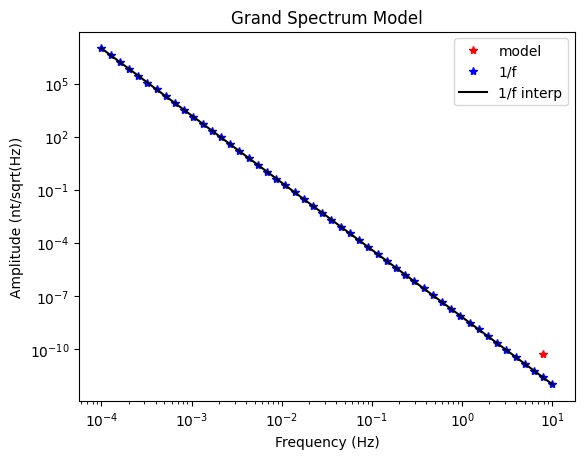

In [6]:
fig, ax = plt.subplots()
ax.loglog(seed_frequency_data_points, seed_amplitude_data_points, 'r*', label="model")
ax.loglog(frequencies, amplitudes, 'b*', label="1/f")
ax.loglog(frequencies, amplitudes, 'k', label="1/f interp")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude (nt/sqrt(Hz))")
ax.set_title("Grand Spectrum Model")
ax.legend()

### TODO: Check if 1/f is for power or amplitude spectra.
Probably better to just get a bunch of observations and fleshout the seed values into something we can interpolate.

In [10]:
# Next Step:

synthetic_data_sample_rate = 1.0  # sps in Hz
synthetic_data_sample_interval = 1.0 / synthetic_data_sample_rate  # sps in Hz
synthetic_data_duration = 400.0  # duration in seconds 
n_samples = int(synthetic_data_sample_rate * synthetic_data_duration)  # Force this to be odd for now

frequency_axis = np.fft.fftfreq(n_samples, d=synthetic_data_sample_interval)
non_negative_frequency_axis = np.fft.rfftfreq(n_samples, d=synthetic_data_sample_interval)

print(len(frequency_axis))
print(len(non_negative_frequency_axis))

# consider also using scipy.interpolate.InterpolatedUnivariateSpline

amplitude_interpolator = scipy.interpolate.interp1d(
    x=np.log(frequencies),
    y=np.log(amplitudes),
    kind="linear",
    fill_value='extrapolate'
)

400
201


In [11]:
non_negative_frequency_axis

array([0.    , 0.0025, 0.005 , 0.0075, 0.01  , 0.0125, 0.015 , 0.0175,
       0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  , 0.0425, 0.045 , 0.0475, 0.05  , 0.0525, 0.055 , 0.0575,
       0.06  , 0.0625, 0.065 , 0.0675, 0.07  , 0.0725, 0.075 , 0.0775,
       0.08  , 0.0825, 0.085 , 0.0875, 0.09  , 0.0925, 0.095 , 0.0975,
       0.1   , 0.1025, 0.105 , 0.1075, 0.11  , 0.1125, 0.115 , 0.1175,
       0.12  , 0.1225, 0.125 , 0.1275, 0.13  , 0.1325, 0.135 , 0.1375,
       0.14  , 0.1425, 0.145 , 0.1475, 0.15  , 0.1525, 0.155 , 0.1575,
       0.16  , 0.1625, 0.165 , 0.1675, 0.17  , 0.1725, 0.175 , 0.1775,
       0.18  , 0.1825, 0.185 , 0.1875, 0.19  , 0.1925, 0.195 , 0.1975,
       0.2   , 0.2025, 0.205 , 0.2075, 0.21  , 0.2125, 0.215 , 0.2175,
       0.22  , 0.2225, 0.225 , 0.2275, 0.23  , 0.2325, 0.235 , 0.2375,
       0.24  , 0.2425, 0.245 , 0.2475, 0.25  , 0.2525, 0.255 , 0.2575,
       0.26  , 0.2625, 0.265 , 0.2675, 0.27  , 0.2725, 0.275 , 0.2775,
      

In [12]:
# frequency_axis

In [13]:
len(frequency_axis)

400

In [18]:
fc_amplitudes = amplitude_interpolator(np.log(frequency_axis[0:int(n_samples/2)]))

/tmp/ipykernel_608124/3359899869.py:1: RuntimeWarning: divide by zero encountered in log
  fc_amplitudes = amplitude_interpolator(np.log(frequency_axis[0:int(n_samples/2)]))


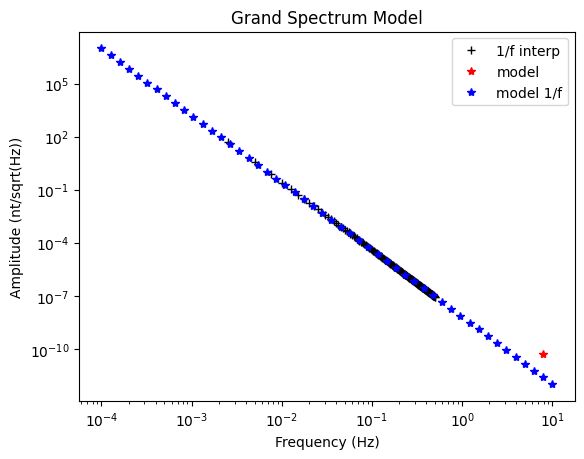

In [19]:
fig, ax = plt.subplots()

ax.loglog(frequency_axis[0:int(n_samples/2)], np.exp(fc_amplitudes[0:int(n_samples/2)]), 'k+', label="1/f interp")
ax.loglog(seed_frequency_data_points, seed_amplitude_data_points, 'r*', label="model")
ax.loglog(frequencies, amplitudes, 'b*', label="model 1/f")
#ax.loglog(frequency_axis[0:int(n_samples/2)], np.exp(interp_ampls[0:int(n_samples/2)]), 'k+', label="1/f interp")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude (nt/sqrt(Hz))")
ax.set_title("Grand Spectrum Model")
ax.legend()

#scipy.signal.resample_poly?

OK, so now we have an intrpolated ampltude spectrum at all of our FFT freqs.

The next step is to generate FCs with amplitudes taken from the grand spectrum

In [20]:
# np.fft.rfftfreq?

# Appendix

## A: Notes on noise

Noise: Some process which couples into the recorded data that makes the residuals larger than they would be otherwise.

Coherent Noise: A noise process that is coherent across one or more channels.

The difference between signal and coherent noise can get blurred at times, but the coherent noise is not yielding helpful estimates of ground impedance, whereas signal is.

Key to the definition of a coherent noise process is that if the coherence-relationship among the channels is known, it has it's own transfer function.  Which is to say that coherent noise in channel 1, say, could be predicted if we know the component of the coherent noise in channels 2 and 3 say.  Not unlike the MT problem, there is a dimensionality consideration, i.e. the MT "answer" is a tensor, and the coherent noise answer can also be a tensor, but it may also be a scalar.  

For example a coherent noise source may be the scalar n(t), and act like

`Noise(t) = a1*n(t)*x_hat + a2*n(t)*y_hat`

In this case we have a scalar noise time series that is detected in more than one component.  Clearly, the x_hat and y_hat componenets of N(t) are coherent, as they are scalar multiples of n(t).

What about vector-valued, or multi-dimensional coherent noise?  Well, it would seem that this would have the form:

Noise1(t) + Noise2(t) where each of Noise1 and Noise2 conform to the above model individually, but Noise1 and Noise2 are themselves, incoherent.  THere would be 4 coefficients to fully characterise this, a1_noise1, a2_noise1, a1_noise2, a2_noise2.  

A real world example of this sort of situation would be the motional noise experienced during an airborne survey.  Each of roll, pitch, and yaw may have their own harmonic amplitudes (and phases) so there are actually 3 separate sources of coherent noise (each characterized by two numbers, and amplitude and a phase).  Each of these has a deterministic coupling with the sensors.

A real world model of these would be done using a small-angle approximation as the assumption we work under is that most of the motion noise has been subtracted before we get to the TF calculation stage, however **N.B.** in Hering 2019, Sec 4, the added noise is 20x the background signal levels and the results look pretty good.